# EDA e ingeniería de variables

## Contexto

Este notebook parte del catálogo **ya limpio** que deja `01_limpieza_y_unificacion_recetas.ipynb`
(`data/processed/recetas_unificadas_limpias.csv`) y responde dos preguntas:

1. **EDA:** ¿el catálogo cubre lo que ChefWise necesita (categoría, tiempo, dificultad, porciones, ingredientes)?
2. **Ingeniería de variables:** ¿qué variables derivadas ayudan al recomendador y a los filtros, y qué tan
   confiables son?

No modifica el CSV: el EDA y las variables se calculan en memoria. Las figuras se guardan en `notebooks/figures/`.

```
01 limpieza → data/processed/*.csv → 02 EDA + variables → 03 modelo TF-IDF → models/*.joblib → backend
```

## 1. Datos y estilo

Funciona tanto si el kernel arranca en `chefWise/` como en `notebooks/`.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)

cwd = Path.cwd().resolve()
if (cwd / "data" / "processed").is_dir():
    PROJECT_DIR = cwd
elif (cwd.parent / "data" / "processed").is_dir():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError("No se encontró data/processed. Abre el notebook desde chefWise/ o notebooks/.")

DATA_PATH = PROJECT_DIR / "data" / "processed" / "recetas_unificadas_limpias.csv"
FIGURES_DIR = PROJECT_DIR / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_DIR))

print("CSV:", DATA_PATH, "| existe:", DATA_PATH.exists())
print("Figuras:", FIGURES_DIR)

CSV: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/data/processed/recetas_unificadas_limpias.csv | existe: True
Figuras: /Users/i./Documents/DIPLOMADO/MODULO_5/chefWise/notebooks/figures


In [2]:
# Paleta y estilo corporativo (alineado a frontend/src/styles.scss)
OLIVE = "#4a5d23"
OLIVE_DARK = "#3a4a1a"
MUSTARD = "#c99a2e"
MUSTARD_SOFT = "#e9cf8f"
BG = "#faf8f2"
SURFACE = "#ffffff"
INK = "#2b2a22"
INK_SOFT = "#6b6a5c"
LINE = "#e6e2d6"
OLIVE_MID = "#6f7f45"
SAND = "#c4b49a"

PALETTE = [OLIVE, MUSTARD, OLIVE_DARK, OLIVE_MID, SAND, "#b08a3e", "#8a9a62"]


def apply_chefwise_style():
    plt.rcParams.update({
        "figure.facecolor": BG,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": LINE,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "grid.color": LINE,
        "grid.linewidth": 0.7,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica Neue", "DejaVu Sans"],
        "font.size": 10.5,
        "axes.titlesize": 13,
        "axes.titleweight": "semibold",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "figure.dpi": 120,
        "savefig.dpi": 170,
        "savefig.facecolor": BG,
        "legend.frameon": False,
    })


def finish_ax(ax, xlabel="", ylabel=""):
    ax.set_xlabel(xlabel, color=INK_SOFT, fontsize=10)
    ax.set_ylabel(ylabel, color=INK_SOFT, fontsize=10)
    ax.tick_params(length=0)
    ax.spines["left"].set_color(LINE)
    ax.spines["bottom"].set_color(LINE)


def save_fig(fig, name: str):
    out = FIGURES_DIR / f"{name}.png"
    fig.savefig(out, bbox_inches="tight", pad_inches=0.32)
    print("Figura:", out.name)
    return out


apply_chefwise_style()
eda = pd.read_csv(DATA_PATH)
print("Filas en EDA:", len(eda), "| columnas:", eda.shape[1])

Filas en EDA: 28853 | columnas: 29


## 2. EDA para el recomendador de ChefWise

Antes de entrenar nada comprobamos si el catálogo sirve para lo que la app hace:

- **Sorpréndeme / inicio:** recetas con nombre, ingredientes, tiempo y dificultad creíbles.
- **Con lo que tengo:** ingredientes parseables (separador ` | `).
- **Filtros de ficha:** categoría (`desayuno`, `comida`, `cena`, `postre`, `bebida`), minutos, porciones.
- **Detalle:** pasos suficientes para cocinar.

Las gráficas usan la paleta de ChefWise (olivo, mostaza, papel) para poder copiarlas a documentación.

### 2.1 ¿De dónde sale el catálogo?

Un recomendador sesgado por fuente recomienda siempre el mismo estilo de cocina.
Kiwilimon aporta recetas mexicanas con tiempos; RecetasGratis aporta volumen y más
variedad de país, pero con más huecos de metadatos.

findfont: Failed to find font weight semibold for Arial, now using 700.


Figura: 01_recetas_por_fuente.png


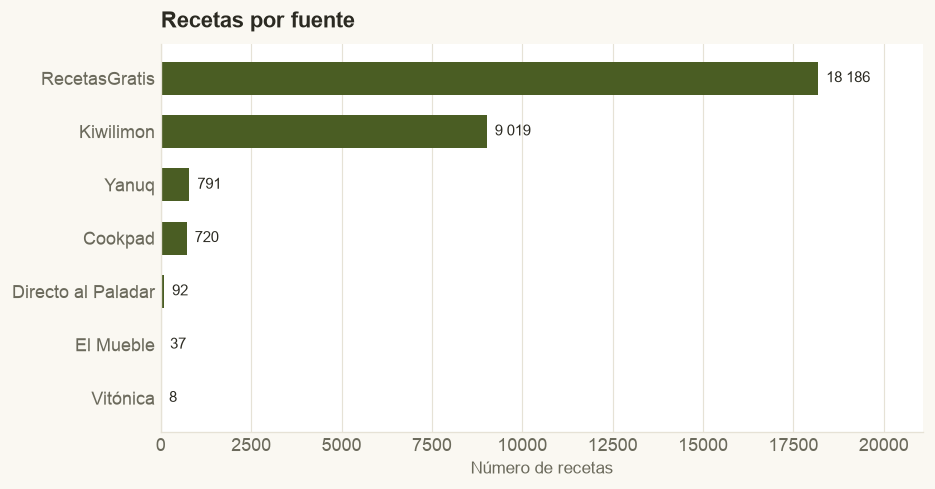

In [3]:
source_counts = eda["source"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8.2, 4.2))
fig.patch.set_facecolor(BG)
bars = ax.barh(source_counts.index, source_counts.values, color=OLIVE, height=0.62)
ax.xaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Recetas por fuente")
finish_ax(ax, xlabel="Número de recetas")
for bar, val in zip(bars, source_counts.values):
    ax.text(val + max(source_counts.values) * 0.012, bar.get_y() + bar.get_height() / 2,
            f"{val:,}".replace(",", " "), va="center", ha="left", color=INK, fontsize=9)
ax.set_xlim(0, source_counts.max() * 1.16)
save_fig(fig, "01_recetas_por_fuente")
plt.show()

### 2.2 Cobertura de campos que la app necesita

La ficha de ChefWise no puede mostrarse bien si faltan categoría, minutos o dificultad.
El porcentaje de nulos aquí es una métrica de producto, no solo de calidad estadística.

Figura: 02_cobertura_campos_app.png


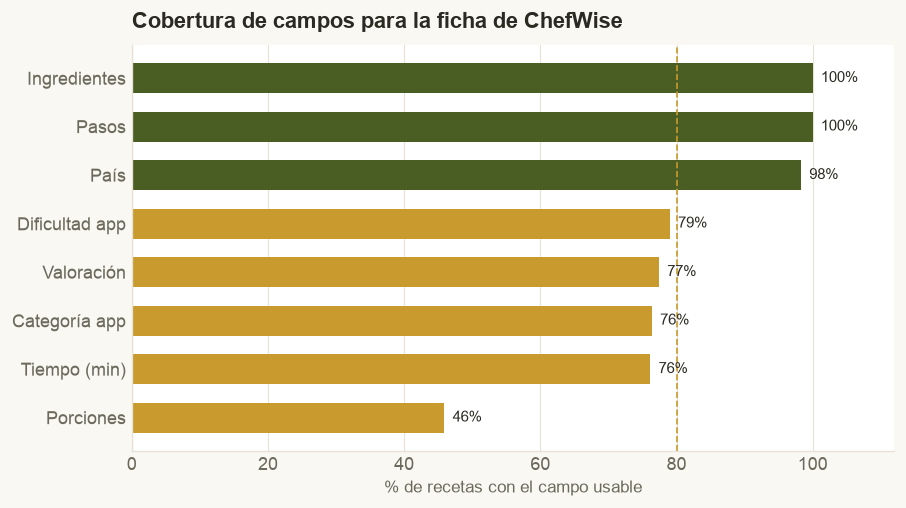

Interpretación: la línea al 80% marca un umbral razonable para filtros en producto.


,% cobertura
Porciones,45.9
Tiempo (min),76.2
Categoría app,76.4
Valoración,77.4
Dificultad app,79.0
País,98.3
Pasos,100.0
Ingredientes,100.0


In [4]:
app_fields = {
    "Ingredientes": eda["ingredients"].fillna("").ne(""),
    "Pasos": eda["instructions"].fillna("").ne(""),
    "Categoría app": eda["app_category"].notna(),
    "Dificultad app": eda["app_difficulty"].notna(),
    "Tiempo (min)": eda["total_time_min"].notna() & (eda["total_time_min"] > 0),
    "Porciones": eda["servings"].notna(),
    "País": eda["country"].notna(),
    "Valoración": eda["rating"].notna(),
}
coverage = pd.Series({k: 100 * v.mean() for k, v in app_fields.items()}).sort_values()

fig, ax = plt.subplots(figsize=(8.2, 4.4))
colors = [MUSTARD if val < 80 else OLIVE for val in coverage.values]
bars = ax.barh(coverage.index, coverage.values, color=colors, height=0.62)
ax.axvline(80, color=MUSTARD, linewidth=1, linestyle="--")
ax.xaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Cobertura de campos para la ficha de ChefWise")
finish_ax(ax, xlabel="% de recetas con el campo usable")
ax.set_xlim(0, 112)
for bar, val in zip(bars, coverage.values):
    ax.text(val + 1.2, bar.get_y() + bar.get_height() / 2, f"{val:.0f}%",
            va="center", fontsize=9, color=INK)
save_fig(fig, "02_cobertura_campos_app")
plt.show()

print("Interpretación: la línea al 80% marca un umbral razonable para filtros en producto.")
display(coverage.round(1).to_frame("% cobertura"))

Figura: 03_completitud_por_fuente.png


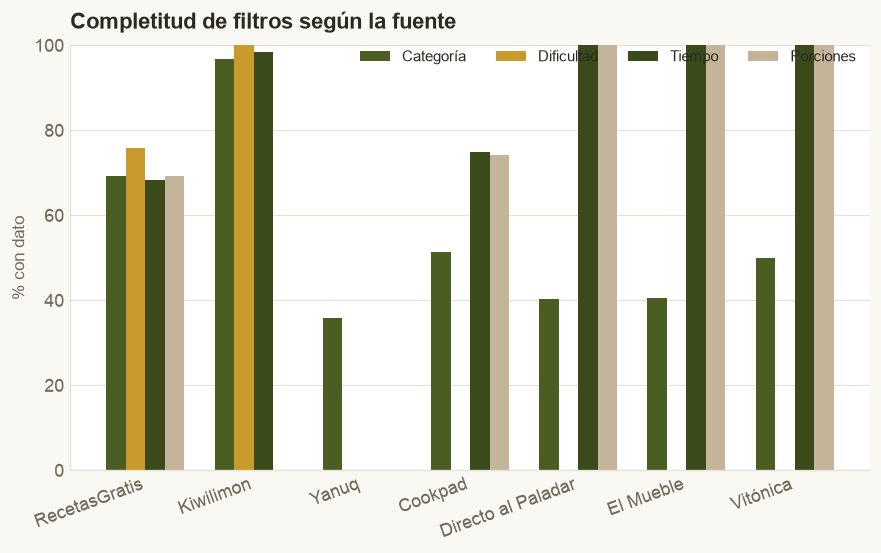

,Categoría,Dificultad,Tiempo,Porciones
source,,,,
RecetasGratis,69.3,75.8,68.3,69.2
Kiwilimon,96.7,100.0,98.5,0.0
Yanuq,35.9,0.0,0.0,0.0
Cookpad,51.2,0.0,74.9,74.2
Directo al Paladar,40.2,0.0,100.0,100.0
El Mueble,40.5,0.0,100.0,100.0
Vitónica,50.0,0.0,100.0,100.0


In [5]:
# Completitud por fuente (los huecos no están repartidos igual)
fields_by_source = (
    eda.assign(
        cat=eda["app_category"].notna(),
        diff=eda["app_difficulty"].notna(),
        time=(eda["total_time_min"].notna()) & (eda["total_time_min"] > 0),
        serv=eda["servings"].notna(),
    )
    .groupby("source")[["cat", "diff", "time", "serv"]]
    .mean()
    .mul(100)
    .reindex(eda["source"].value_counts().index)
)
fields_by_source.columns = ["Categoría", "Dificultad", "Tiempo", "Porciones"]

fig, ax = plt.subplots(figsize=(8.6, 4.6))
x = np.arange(len(fields_by_source))
width = 0.18
for i, (col, color) in enumerate(zip(fields_by_source.columns, [OLIVE, MUSTARD, OLIVE_DARK, SAND])):
    ax.bar(x + (i - 1.5) * width, fields_by_source[col], width=width, color=color, label=col)
ax.set_xticks(x)
ax.set_xticklabels(fields_by_source.index, rotation=20, ha="right")
ax.set_ylim(0, 100)
ax.yaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(ncol=4, loc="upper right", bbox_to_anchor=(1, 1.02), fontsize=9)
ax.set_title("Completitud de filtros según la fuente")
finish_ax(ax, ylabel="% con dato")
save_fig(fig, "03_completitud_por_fuente")
plt.show()
display(fields_by_source.round(1))

### 2.3 Categoría de comida

La app solo tiene cinco casillas. Si muchas recetas quedan sin categoría, “Sorpréndeme”
y el resumen de Mi cocina se sesgan hacia `comida` y `postre`.

Figura:

 04_categoria_app.png


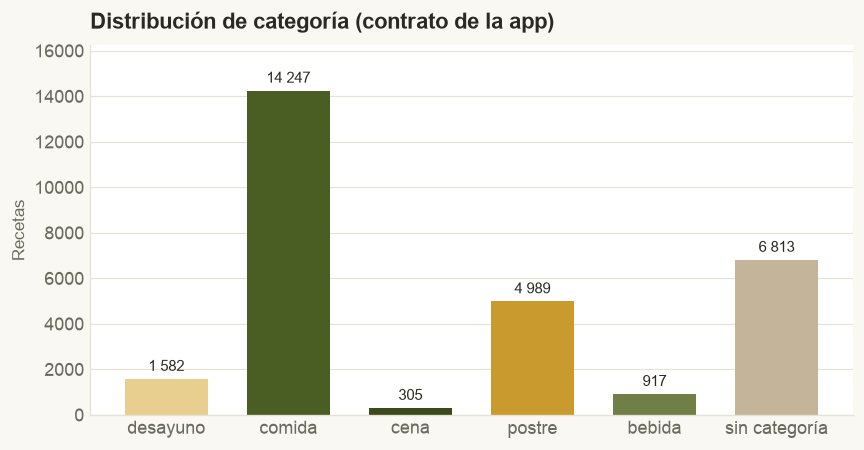

Sin categoría: 6813 (23.6%)


In [6]:
cat_order = ["desayuno", "comida", "cena", "postre", "bebida", "sin categoría"]
cat = eda["app_category"].fillna("sin categoría")
cat_counts = cat.value_counts().reindex(cat_order).fillna(0).astype(int)
cat_colors = {
    "desayuno": MUSTARD_SOFT,
    "comida": OLIVE,
    "cena": OLIVE_DARK,
    "postre": MUSTARD,
    "bebida": OLIVE_MID,
    "sin categoría": SAND,
}

fig, ax = plt.subplots(figsize=(8.2, 4.0))
bars = ax.bar(cat_counts.index, cat_counts.values,
              color=[cat_colors[c] for c in cat_counts.index], width=0.68)
ax.yaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Distribución de categoría (contrato de la app)")
finish_ax(ax, ylabel="Recetas")
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + max(cat_counts.values) * 0.015,
            f"{val:,}".replace(",", " "), ha="center", va="bottom", fontsize=9, color=INK)
ax.set_ylim(0, cat_counts.max() * 1.14)
save_fig(fig, "04_categoria_app")
plt.show()
print("Sin categoría:", int(cat_counts["sin categoría"]),
      f"({100 * cat_counts['sin categoría'] / cat_counts.sum():.1f}%)")

### 2.4 Tiempo de preparación

En la tarjeta de ChefWise, `minutes` es un número que la persona usa para decidir
si cocina hoy. Valores de 0 minutos o de varios días (vinagre, o `30h` mal scrapeado)
rompen ese filtro.

En el CSV final `total_time_min` ya excluye esos casos (0 min y más de 12 h); `listed_time_min` conserva el valor original para auditar.

Nulos: 6878
Igual a 0: 0
> 4 horas: 217
> 12 horas: 0
> 24 horas: 0
count    21975.0
mean        51.8
std         52.0
min          1.0
50%         40.0
90%         90.0
95%        150.0
99%        240.0
max        720.0
Name: total_time_min, dtype: float64


Figura: 05_tiempo_hasta_3h.png


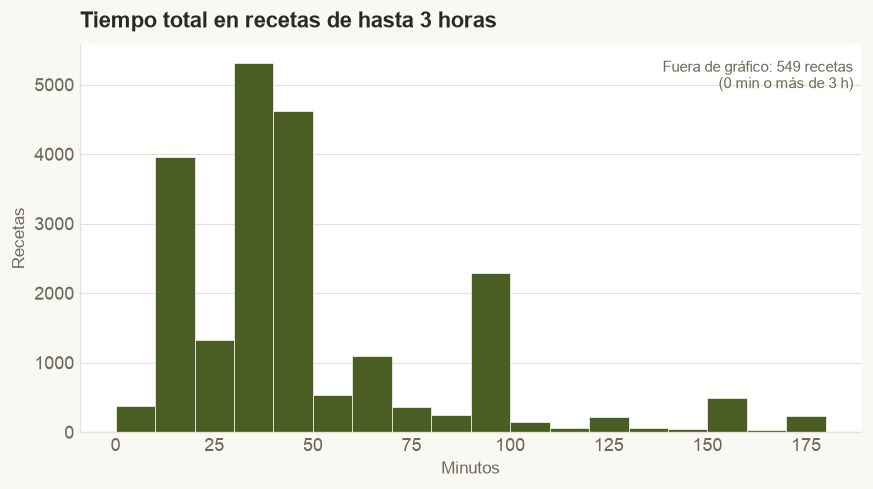


Tiempos largos que se descartaron de la ficha (listed_time_min > 12 h):


,name,source,listed_time_min,total_time_min
25527,Vinagre de Piña,Kiwilimon,30240.0,NaN
10607,Cupcakes de Banano,Kiwilimon,3088.0,110.466667
21348,Bacalao InstaFit,Kiwilimon,2880.0,NaN
21055,Falafel con Ensalada,Kiwilimon,1495.0,NaN
25633,Yogurt Natural,Kiwilimon,1474.0,NaN
21684,Helado de Arroz con Leche de Coco Reducido en Azúcar,Kiwilimon,1460.0,NaN
21969,Paletas Heladas de Limón con Pulparindo,Kiwilimon,1450.0,NaN
22359,Chicharrón de Cerdo,Kiwilimon,1450.0,NaN


In [7]:
times = eda["total_time_min"]
print("Nulos:", int(times.isna().sum()))
print("Igual a 0:", int((times == 0).sum()))
print("> 4 horas:", int((times > 240).sum()))
print("> 12 horas:", int((times > 720).sum()))
print("> 24 horas:", int((times > 1440).sum()))
print(times.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))

# Histograma en el rango útil para una comida casera (hasta 3 h); los outliers se reportan aparte
plot_times = times[(times > 0) & (times <= 180)]

fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.hist(plot_times, bins=np.arange(0, 185, 10), color=OLIVE, edgecolor=SURFACE, linewidth=0.4)
ax.yaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Tiempo total en recetas de hasta 3 horas")
finish_ax(ax, xlabel="Minutos", ylabel="Recetas")
n_out = int(((times > 180) | (times == 0)).sum())
ax.text(0.99, 0.96,
        f"Fuera de gráfico: {n_out:,} recetas\n(0 min o más de 3 h)".replace(",", " "),
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color=INK_SOFT)
save_fig(fig, "05_tiempo_hasta_3h")
plt.show()

print("\nTiempos largos que se descartaron de la ficha (listed_time_min > 12 h):")
display(
    eda.loc[eda["listed_time_min"] > 720, ["name", "source", "listed_time_min", "total_time_min"]]
    .sort_values("listed_time_min", ascending=False)
    .head(8)
)

### 2.5 Dificultad, porciones e ingredientes

Sirven para filtrar “fácil / en 30 min / para 2” y para el motor de “con lo que tengo”.

Figura: 06_dificultad_e_ingredientes.png


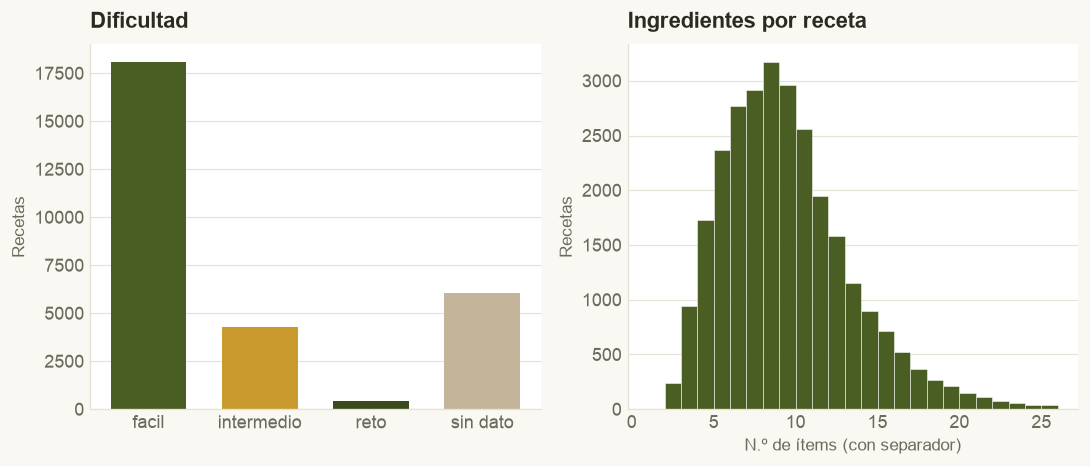

Porciones (cuando existen): mediana 4.0 | p95 10.0 | máx 100.0
Recetas sin conteo estructurado de ingredientes: 985


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0))
fig.patch.set_facecolor(BG)

diff = eda["app_difficulty"].fillna("sin dato")
diff_order = ["facil", "intermedio", "reto", "sin dato"]
diff_counts = diff.value_counts().reindex(diff_order).fillna(0)
diff_colors = [OLIVE, MUSTARD, OLIVE_DARK, SAND]
axes[0].bar(diff_counts.index, diff_counts.values, color=diff_colors, width=0.68)
axes[0].yaxis.grid(True, color=LINE, linewidth=0.7)
axes[0].set_axisbelow(True)
axes[0].set_title("Dificultad")
finish_ax(axes[0], ylabel="Recetas")

ing = eda["n_ingredients_approx"].dropna()
ing_clip = ing[ing <= 25]
axes[1].hist(ing_clip, bins=np.arange(1, 27, 1), color=OLIVE, edgecolor=SURFACE, linewidth=0.3)
axes[1].yaxis.grid(True, color=LINE, linewidth=0.7)
axes[1].set_axisbelow(True)
axes[1].set_title("Ingredientes por receta")
finish_ax(axes[1], xlabel="N.º de ítems (con separador)", ylabel="Recetas")

plt.tight_layout()
save_fig(fig, "06_dificultad_e_ingredientes")
plt.show()

serv = eda["servings"].dropna()
print("Porciones (cuando existen): mediana", float(serv.median()), "| p95", float(serv.quantile(0.95)), "| máx", float(serv.max()))
print("Recetas sin conteo estructurado de ingredientes:", int(eda["n_ingredients_approx"].isna().sum()))

### 2.6 País y duplicados entre fuentes

El recomendador puede filtrar cocina mexicana vs española, pero Kiwilimon está etiquetado
México por origen del sitio. Los duplicados de nombre entre fuentes (p. ej. agua de horchata
en RecetasGratis y Kiwilimon) harían que el ranking muestre la misma idea dos veces.

Figura: 07_pais.png


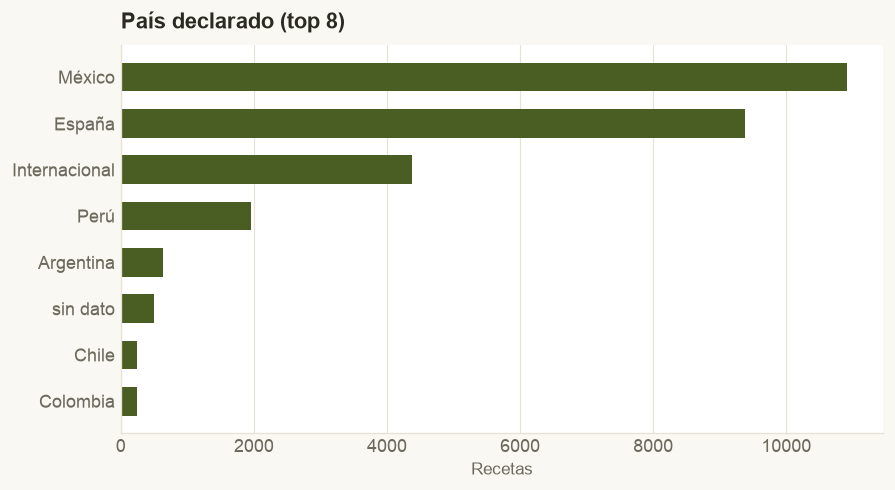

Filas que comparten nombre normalizado: 1511 en 699 nombres
URLs repetidas (Yanuq/El Mueble no traen URL única): 826


In [9]:
country = eda["country"].fillna("sin dato").value_counts().head(8).sort_values()

fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.barh(country.index, country.values, color=OLIVE, height=0.62)
ax.xaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("País declarado (top 8)")
finish_ax(ax, xlabel="Recetas")
save_fig(fig, "07_pais")
plt.show()

dup_name = eda.duplicated("name_key", keep=False)
print("Filas que comparten nombre normalizado:", int(dup_name.sum()),
      "en", eda.loc[dup_name, "name_key"].nunique(), "nombres")
print("URLs repetidas (Yanuq/El Mueble no traen URL única):", int(eda["url"].duplicated().sum()))

## 3. Lectura del EDA

Con el catálogo ya limpio (28 853 recetas):

- **Ingredientes y pasos:** 100 % de las recetas traen ingredientes y 4 no traen pasos (se dejan vacías a propósito,
  no se inventan). Es lo único que la ficha de detalle exige sí o sí.
- **Cobertura desigual por fuente:** categoría, dificultad y tiempo están entre 76 % y 79 %; porciones, solo 46 %.
  Yanuq no trae dificultad, tiempo ni porciones; Kiwilimón no trae porciones. Cualquier filtro por esos campos
  sesga hacia las fuentes que sí los traen (las recetas sin dato quedan fuera del filtro).
- **Categoría:** 23.6 % de las recetas quedan sin categoría tras inferirla desde `meal_type` y el nombre.
- **Tiempo:** `total_time_min` ya no tiene ceros ni valores de más de 12 h. La mediana es de 40 min y el p95, de
  150 min; hay 217 recetas de más de 4 h.
- **Duplicados:** quedan 1 511 filas que comparten nombre normalizado en 699 nombres. Son recetas con ingredientes
  distintos (si no, `01` ya las habría fusionado), pero el recomendador puede sugerir "la misma receta" dos veces.
  Vale la pena diversificar el top-N por nombre.

## 4. Ingeniería de variables

Variables que el recomendador y la app consumen, de dónde salen y cuáles se derivan aquí.

| Variable | Origen | Para qué sirve |
| --- | --- | --- |
| `recipe_text` | `01` (nombre + ingredientes + tags + país + dificultad) | Entrada del TF-IDF. **No** incluye pasos. |
| `app_category`, `app_difficulty`, `total_time_min`, `servings`, `country` | `01` | Filtros duros de Sorpréndeme. |
| `n_ingredients_approx`, `n_steps_approx` | `01` | Conteos aproximados (nulos si la fuente no separa con ` \| `). |
| `n_ingredients`, `n_steps` | **aquí**, con `src.text_utils` (el mismo parser que el backend) | Conteos completos y consistentes con lo que ve la app. |
| `time_bucket`, `is_quick` | **aquí**; `is_quick` usa `QUICK_MAX_MINUTES` de `src/config.py` | Segmentos de tiempo y el antojo "rápido". |
| `recipe_text_words` | **aquí** | Revisar que el texto del modelo no esté vacío ni desbalanceado. |
| `core_ingredient` | **aquí** | Ingrediente sin cantidad ni unidad, para "con lo que tengo". |

In [10]:
from src.config import QUICK_MAX_MINUTES
from src.text_utils import split_ingredients, split_steps

feat = eda[["recipe_id", "source", "app_category", "app_difficulty", "total_time_min", "rating",
            "n_ingredients_approx", "n_steps_approx"]].copy()

feat["n_ingredients"] = eda["ingredients"].map(lambda t: len(split_ingredients(t)))
feat["n_steps"] = eda["instructions"].map(lambda t: len(split_steps(t)))
feat["recipe_text_words"] = eda["recipe_text"].fillna("").str.split().str.len()

TIME_LABELS = ["≤ 15 min", "16–30 min", "31–60 min", "1–2 h", "> 2 h"]
feat["time_bucket"] = (
    pd.cut(feat["total_time_min"], bins=[0, 15, 30, 60, 120, np.inf], labels=TIME_LABELS)
    .astype("object").fillna("sin dato")
)
feat["is_quick"] = feat["total_time_min"].le(QUICK_MAX_MINUTES)

print(f"Tope de 'rápido' (src/config.py): {QUICK_MAX_MINUTES} min")
print("Cobertura de conteos aproximados vs completos:")
display(pd.DataFrame({
    "aproximado (CSV)": feat[["n_ingredients_approx", "n_steps_approx"]].notna().mean().mul(100).round(1).values,
    "completo (aquí)": [100.0 * (feat["n_ingredients"] > 0).mean(), 100.0 * (feat["n_steps"] > 0).mean()],
}, index=["ingredientes", "pasos"]).rename_axis("% de recetas con conteo"))
display(feat[["n_ingredients", "n_steps", "recipe_text_words"]].describe(percentiles=[.5, .9, .99]).T.round(1))

Tope de 'rápido' (src/config.py): 30 min
Cobertura de conteos aproximados vs completos:


,aproximado (CSV),completo (aquí)
% de recetas con conteo,,
ingredientes,96.6,100.000000
pasos,100.0,99.986137


,count,mean,std,min,50%,90%,99%,max
n_ingredients,28853.0,9.2,4.3,1.0,9.0,15.0,23.0,50.0
n_steps,28853.0,6.0,3.0,0.0,6.0,10.0,16.0,54.0
recipe_text_words,28853.0,71.0,32.0,8.0,66.0,108.0,182.5,528.0


### 4.1 Ingredientes, pasos y largo del texto del modelo

Una receta con 1–2 ingredientes o sin pasos es mala candidata para "Con lo que tengo" y para el detalle.
Un `recipe_text` muy corto da vectores TF-IDF casi vacíos.

Figura: 10_ingredientes_pasos_texto.png


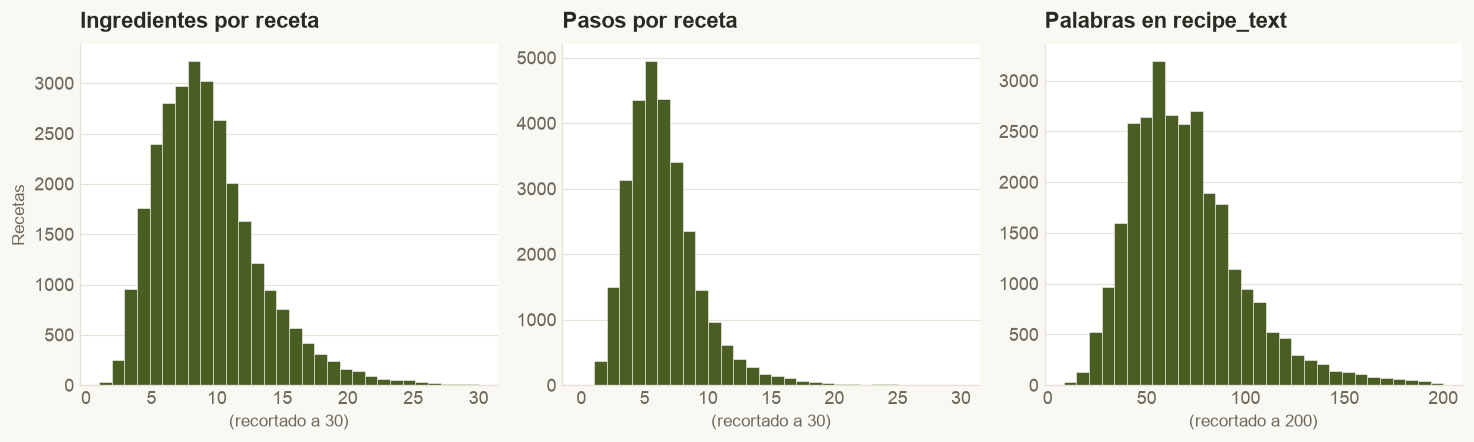

Recetas con 0 ingredientes: 0 | con ≤ 2 ingredientes: 284
Recetas con 0 pasos: 4 | con 1 solo paso: 371
recipe_text con < 8 palabras: 0


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12.4, 3.8))
fig.patch.set_facecolor(BG)
for ax, col, clip, title in [
    (axes[0], "n_ingredients", 30, "Ingredientes por receta"),
    (axes[1], "n_steps", 30, "Pasos por receta"),
    (axes[2], "recipe_text_words", 200, "Palabras en recipe_text"),
]:
    s = feat[col].dropna()
    s = s[s <= clip]
    ax.hist(s, bins=min(30, clip), color=OLIVE, edgecolor=SURFACE, linewidth=0.3)
    ax.yaxis.grid(True, color=LINE, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.set_title(title)
    finish_ax(ax, xlabel=f"(recortado a {clip})", ylabel="Recetas" if ax is axes[0] else "")
plt.tight_layout()
save_fig(fig, "10_ingredientes_pasos_texto")
plt.show()

print("Recetas con 0 ingredientes:", int((feat["n_ingredients"] == 0).sum()),
      "| con ≤ 2 ingredientes:", int((feat["n_ingredients"] <= 2).sum()))
print("Recetas con 0 pasos:", int((feat["n_steps"] == 0).sum()),
      "| con 1 solo paso:", int((feat["n_steps"] == 1).sum()))
print("recipe_text con < 8 palabras:", int((feat["recipe_text_words"] < 8).sum()))

### 4.2 Segmentos de tiempo y el antojo "rápido"

`is_quick` es la regla que el backend usa para el antojo "rápido" (`total_time_min <= 30`). Las recetas sin tiempo
**nunca** cuentan como rápidas: eso es una decisión de producto, no un dato.

Figura: 11_segmentos_de_tiempo.png


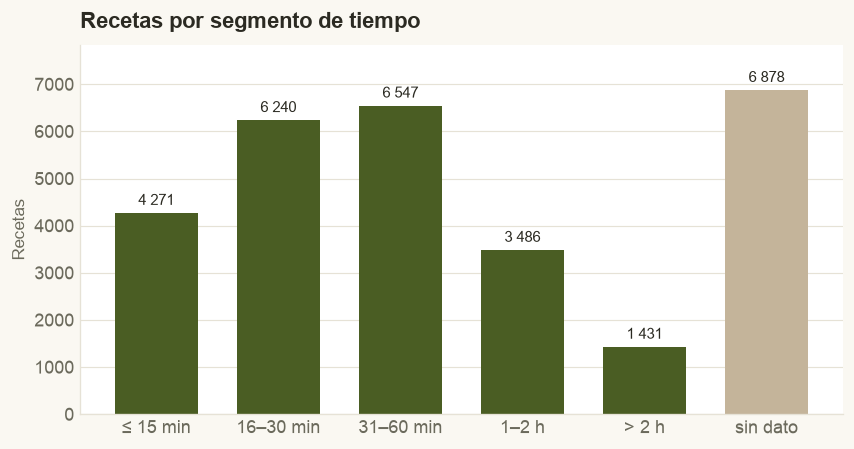

Rápidas (≤ 30 min): 10,511 = 36.4% del catálogo, 47.8% de las que tienen tiempo


is_quick,no rápida / sin dato,rápida
source,,
Cookpad,75.1,24.9
Directo al Paladar,50.0,50.0
El Mueble,51.4,48.6
Kiwilimon,56.0,44.0
RecetasGratis,65.4,34.6
Vitónica,50.0,50.0
Yanuq,100.0,0.0


In [12]:
order = TIME_LABELS + ["sin dato"]
bucket = feat["time_bucket"].value_counts().reindex(order).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(8.2, 4.0))
bars = ax.bar(bucket.index, bucket.values,
              color=[OLIVE] * len(TIME_LABELS) + [SAND], width=0.68)
ax.yaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Recetas por segmento de tiempo")
finish_ax(ax, ylabel="Recetas")
for bar, val in zip(bars, bucket.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + bucket.max() * 0.015, f"{val:,}".replace(",", " "),
            ha="center", va="bottom", fontsize=9, color=INK)
ax.set_ylim(0, bucket.max() * 1.14)
save_fig(fig, "11_segmentos_de_tiempo")
plt.show()

known = feat["total_time_min"].notna()
print(f"Rápidas (≤ {QUICK_MAX_MINUTES} min): {int(feat['is_quick'].sum()):,} "
      f"= {100 * feat['is_quick'].mean():.1f}% del catálogo, {100 * feat.loc[known, 'is_quick'].mean():.1f}% de las que tienen tiempo")
display(pd.crosstab(feat["source"], feat["is_quick"], normalize="index").mul(100).round(1)
        .rename(columns={False: "no rápida / sin dato", True: "rápida"}))

### 4.3 ¿Dificultad, tiempo y pasos cuentan la misma historia?

Si `facil` no fuera más corta y simple que `reto`, el filtro de dificultad no tendría valor para el usuario.

,mediana minutos,mediana pasos,mediana ingredientes
app_difficulty,,,
facil,30.0,5.0,8.0
intermedio,45.0,7.0,10.0
reto,90.0,6.0,10.0


Figura: 12_dificultad_vs_variables.png


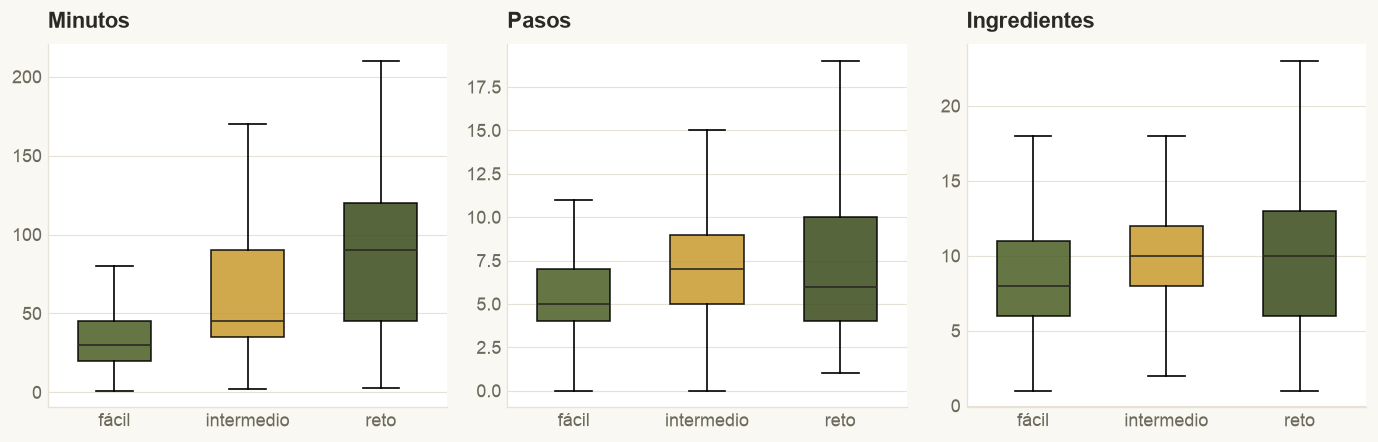

In [13]:
by_diff = (
    feat.dropna(subset=["app_difficulty"])
    .groupby("app_difficulty")[["total_time_min", "n_steps", "n_ingredients"]]
    .median()
    .reindex(["facil", "intermedio", "reto"])
)
display(by_diff.round(1).rename(columns={"total_time_min": "mediana minutos", "n_steps": "mediana pasos",
                                          "n_ingredients": "mediana ingredientes"}))

fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.8))
fig.patch.set_facecolor(BG)
for ax, col, title, ymax in [(axes[0], "total_time_min", "Minutos", 240), (axes[1], "n_steps", "Pasos", 25),
                             (axes[2], "n_ingredients", "Ingredientes", 30)]:
    data = [feat.loc[(feat["app_difficulty"] == d) & feat[col].notna() & (feat[col] <= ymax), col]
            for d in ["facil", "intermedio", "reto"]]
    bp = ax.boxplot(data, tick_labels=["fácil", "intermedio", "reto"], patch_artist=True, showfliers=False,
                    medianprops={"color": INK}, widths=0.55)
    for patch, color in zip(bp["boxes"], [OLIVE, MUSTARD, OLIVE_DARK]):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    ax.yaxis.grid(True, color=LINE, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.set_title(title)
    finish_ax(ax)
plt.tight_layout()
save_fig(fig, "12_dificultad_vs_variables")
plt.show()

### 4.4 Ingredientes más comunes (`core_ingredient`)

"Con lo que tengo" compara lo que escribe la persona contra los ingredientes de cada receta. Para eso conviene
quitar cantidades y unidades (`2 tazas de harina` → `harina`) y ver qué ingredientes dominan el catálogo.

Figura: 13_ingredientes_frecuentes.png


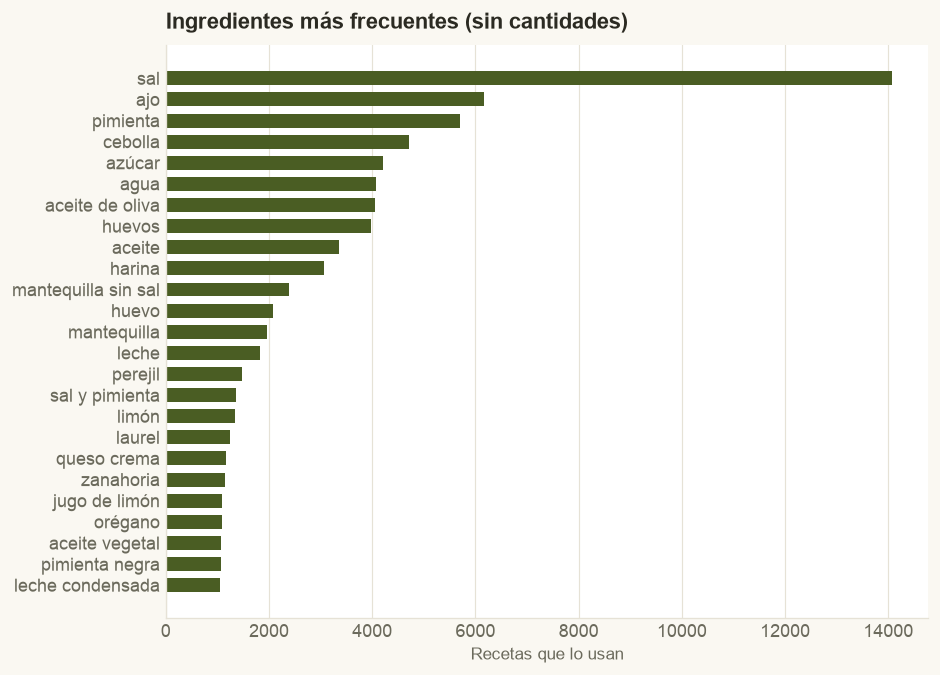

Ingredientes distintos: 35,356 | los 25 primeros cubren 29.1% de las menciones
Ingredientes que aparecen en una sola receta: 25,391 (72% del vocabulario)


In [14]:
UNITS = (r"(?:gramos?|grs?\.?|gr|kilos?|kg|mililitros?|ml|litros?|lt|tazas?|cucharad(?:a|ita)s?|cdas?\.?|cditas?\.?|cucharas?|"
         r"piezas?|unidades?|dientes?|latas?|paquetes?|pizcas?|rebanadas?|hojas?|ramas?|pu[ñn]ados?|onzas?|oz|libras?|lb|"
         r"botellas?|sobres?|barras?|trozos?|cubos?|chorr(?:o|ito)s?|cantidad\s+suficiente|al\s+gusto)")


def core_ingredient(line: str) -> str:
    s = re.sub(r"\([^)]*\)", " ", line.lower())
    s = re.sub(r"^[\d\s/½¼¾.,\-]+", "", s)
    for _ in range(3):
        s = re.sub(rf"^(?:{UNITS}|de|del|la|el|los|las|un|una|unos|unas|grandes?|medianos?|peque[ñn]os?)\b\.?\s*", "", s)
    s = re.split(r",| para | al gusto| o ", s)[0]
    return s.strip(" .-")


core_per_recipe = eda["ingredients"].map(lambda t: {core_ingredient(i) for i in split_ingredients(t)} - {""})
core_counts = pd.Series([c for s in core_per_recipe for c in s]).value_counts()
top = core_counts.head(25).sort_values()

fig, ax = plt.subplots(figsize=(8.2, 6.2))
ax.barh(top.index, top.values, color=OLIVE, height=0.66)
ax.xaxis.grid(True, color=LINE, linewidth=0.7)
ax.set_axisbelow(True)
ax.set_title("Ingredientes más frecuentes (sin cantidades)")
finish_ax(ax, xlabel="Recetas que lo usan")
save_fig(fig, "13_ingredientes_frecuentes")
plt.show()

print(f"Ingredientes distintos: {core_counts.size:,} | los 25 primeros cubren "
      f"{100 * top.sum() / core_counts.sum():.1f}% de las menciones")
print(f"Ingredientes que aparecen en una sola receta: {int((core_counts == 1).sum()):,} "
      f"({100 * (core_counts == 1).mean():.0f}% del vocabulario)")

### 4.5 Vocabulario del TF-IDF y fugas de ruido

Con la misma configuración que `03_recomendador_content_based.ipynb` revisamos qué aprende el modelo.
Si quedaran marcas o autopromoción en `recipe_text`, el TF-IDF las trataría como señal de similitud.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X = tfidf.fit_transform(eda["recipe_text"].fillna("").astype(str))
vocab = pd.Series(tfidf.get_feature_names_out())
doc_freq = pd.Series(np.asarray((X > 0).sum(axis=0)).ravel(), index=vocab)

print("Matriz:", X.shape, "| densidad:", f"{X.nnz / (X.shape[0] * X.shape[1]):.4%}")
print("\nTérminos más frecuentes:")
display(doc_freq.sort_values(ascending=False).head(15).to_frame("recetas"))

LEAK_RX = re.compile(r"tabasco|coca cola|pepsi|baileys|\bmilo\b|kit ?kat|nesquik|nescafe|cointreau|sriracha|avecrem|"
                     r"galletas maria|\boreo|knorr|nutella|philadelphia|maizena|splenda|thermomix|kiwilimon|instagram|youtube|facebook",
                     re.I)
leaks = doc_freq[doc_freq.index.str.contains(LEAK_RX)]
print("Términos del vocabulario con marcas o autopromoción:", len(leaks))
display(leaks.sort_values(ascending=False).head(10).to_frame("recetas"))

assert not eda["recipe_text"].fillna("").str.contains(r"\d+ (?:Mezcla|Agrega|Hornea)", regex=True).any(), \
    "recipe_text no debe incluir pasos"

Matriz: (28853, 63143) | densidad: 0.1142%

Términos más frecuentes:


,recetas
de,28529
sal,18411
baja,18110
en,16161
comida,14257
sin,13971
aceite,12763
gramos,12710
gramos de,11991
taza,10964


Términos del vocabulario con marcas o autopromoción: 2


,recetas
tabasco,3
de tabasco,2


## 5. Qué sale de este notebook

**Variables útiles para el modelo y la app**

- `n_ingredients` y `n_steps` (con el parser del backend) cubren 100 % de las recetas; los conteos aproximados
  del CSV cubren 96.6 % en ingredientes. Conviene usar los de aquí.
- Mediana de 9 ingredientes y 6 pasos. Hay 284 recetas con 2 ingredientes o menos y 371 con un solo paso: son
  malas candidatas para "Con lo que tengo" y para el detalle, y se pueden penalizar en el ranking.
- `is_quick` marca 36.4 % del catálogo (47.8 % de las recetas con tiempo). Es una proporción sana para el antojo
  "rápido". Yanuq no aporta ninguna porque no trae tiempo.
- La dificultad sí separa por tiempo (mediana de 30, 45 y 90 min para fácil, intermedio y reto). No separa tanto
  por pasos ni por ingredientes (`reto` no tiene más pasos que `intermedio`): para el usuario, dificultad se lee
  sobre todo como tiempo.

**Sobre el vocabulario TF-IDF**

- 63 143 términos sobre 28 853 recetas; la matriz tiene una densidad de 0.11 %, y es barata de guardar y consultar.
- Los términos más frecuentes son de relleno: `de`, `en`, `baja`, `comida`, `mexico`, `gramos`. Salen de que
  `recipe_text` incluye país, categoría y dificultad en casi todas las filas. El idf les da poco peso, pero
  no aportan similitud.
- Quedan 2 términos de marca: `tabasco` (3 recetas), que es el estado mexicano ("Barbacoa Blanca de Tabasco"),
  no la salsa.
- El vocabulario se calcula con la configuración de `03`, así que cualquier cambio en un notebook debe replicarse
  en el otro.

**Siguiente paso:** `03_recomendador_content_based.ipynb` entrena y guarda `models/*.joblib`.